In [118]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [119]:
titanic = sns.load_dataset("titanic")

In [120]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [121]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [122]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [123]:
# let select some feature and work on it
feature = ["pclass", "sex", "fare", "embarked","age"]
target = ["survived"]

In [124]:
# import the imputer to fill the missing values
from sklearn.impute import SimpleImputer

In [125]:
# remove all null using imputer and replace with mean  median ,mode

# numerical data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# categorical data
imp_freq1 = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq1.fit_transform(titanic[["embarked"]])

# categorical data
imp_freq2 = SimpleImputer(strategy="most_frequent")
titanic[["embark_town"]] = imp_freq2.fit_transform(titanic[["embark_town"]])

# categorical data
imp_freq3 = SimpleImputer(strategy="most_frequent")
titanic[["deck"]] = imp_freq3.fit_transform(titanic[["deck"]])


In [126]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [127]:
# now we do level encoder
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True


In [128]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [129]:
titanic.head(300)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,C,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,C,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0,1,1,28.0,0,0,27.7208,0,First,man,True,C,Cherbourg,no,True
296,0,3,1,23.5,0,0,7.2292,0,Third,man,True,C,Cherbourg,no,True
297,0,1,0,2.0,1,2,151.5500,2,First,child,False,C,Southampton,no,False
298,1,1,1,28.0,0,0,30.5000,2,First,man,True,C,Southampton,yes,True


In [130]:
# split features
X = titanic[feature]
y = titanic[target]

In [131]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [132]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size = 0.2 ,random_state = 42
)

In [134]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [135]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [136]:
# decision tree model - no pruning
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [137]:
y_pred = model.predict(X_test)

In [138]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\naccuracy_score:\n", accuracy_score(y_test, y_pred))

F1 score: 0.7435897435897436

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.77      0.80       105
           1       0.71      0.78      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179


Confusion Matrix:
 [[81 24]
 [16 58]]

accuracy_score:
 0.776536312849162


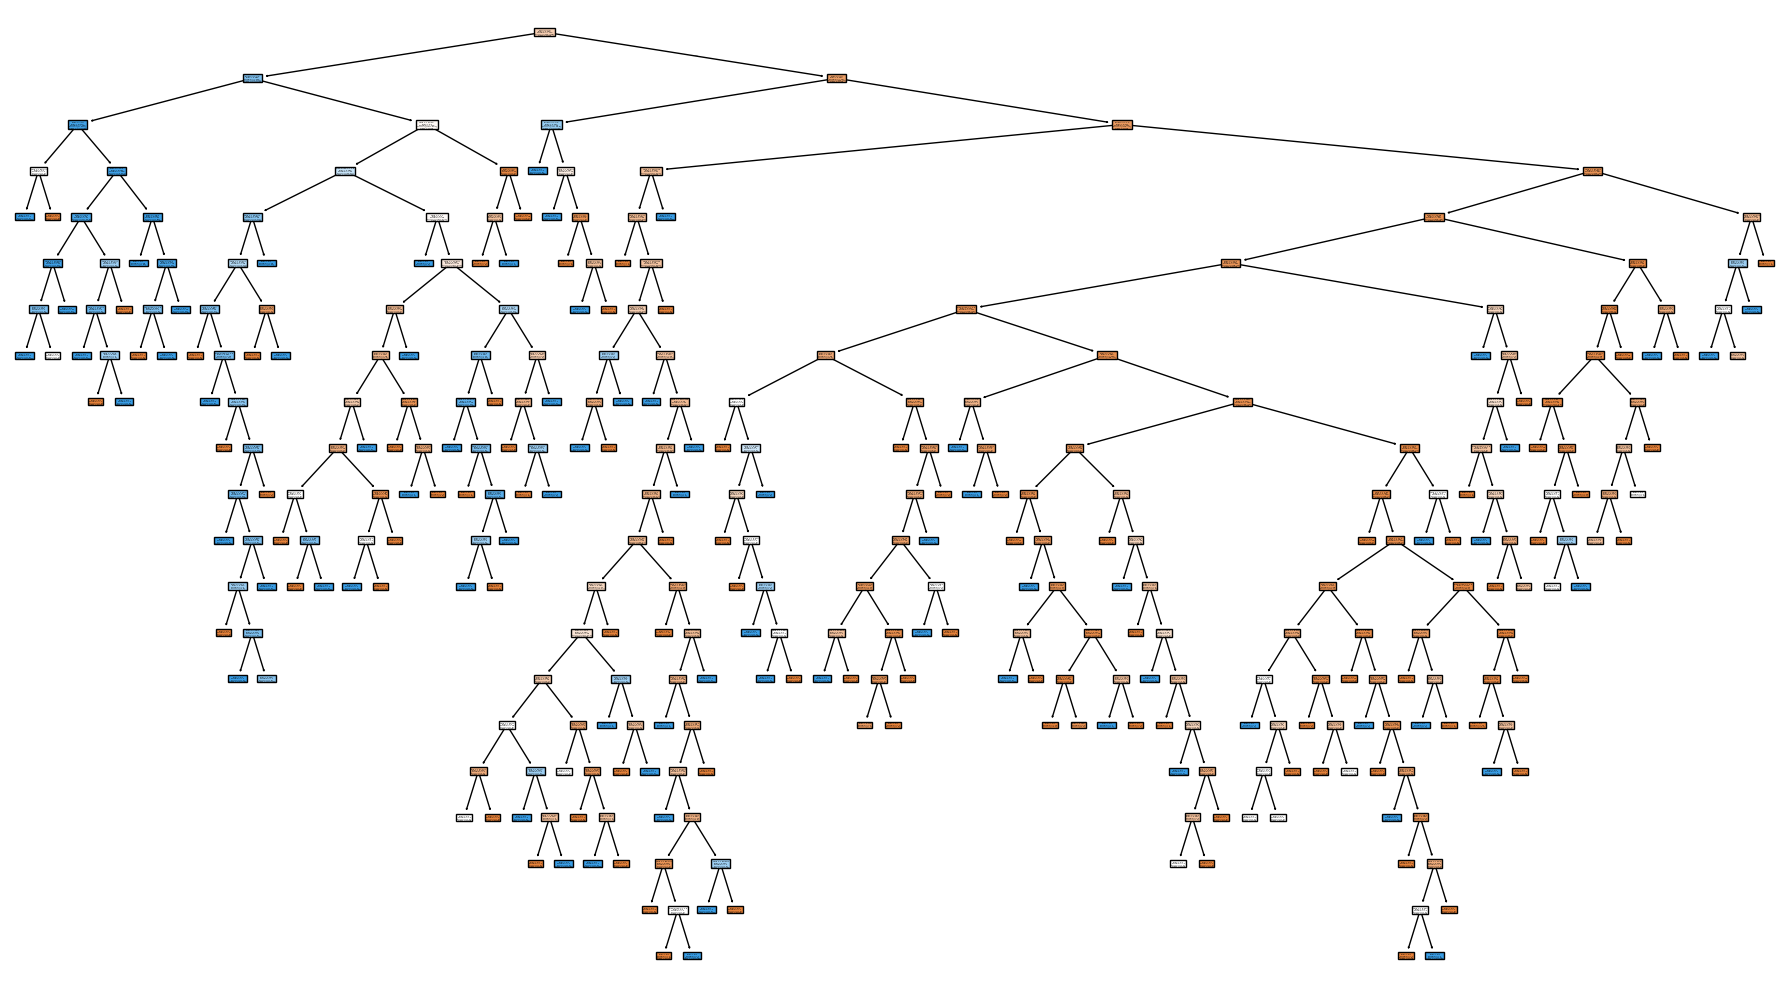

In [139]:
# plot eecision tree
from sklearn.tree import plot_tree

plt.figure(figsize = (18,10))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    # fontsize=20,
    # max_depth = 2
)

plt.tight_layout()
plt.show()


## Decision tree with pre-pruning

In [140]:
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    y_pred = model.predict(X_test)
    # print(f"for depth={depth}, accuracy = {accuracy}")
    print(f"for depth={depth}, accuracy = {accuracy_score(y_test, y_pred)}")

for depth=2, accuracy = 0.7653631284916201
for depth=3, accuracy = 0.7988826815642458
for depth=4, accuracy = 0.7988826815642458
for depth=5, accuracy = 0.7988826815642458
for depth=6, accuracy = 0.8044692737430168
for depth=7, accuracy = 0.7932960893854749
for depth=8, accuracy = 0.7988826815642458
for depth=9, accuracy = 0.7932960893854749
for depth=10, accuracy = 0.7821229050279329


In [141]:
min_samples_split = [5, 10, 15, 20, 25, 30, 35]

for split in min_samples_split:
    model = DecisionTreeClassifier(
        max_depth=6, 
        min_samples_split = split
    )
    model.fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    print(f"for split={split}, accuracy = {accuracy}")

for split=5, accuracy = 0.7988826815642458
for split=10, accuracy = 0.8100558659217877
for split=15, accuracy = 0.8044692737430168
for split=20, accuracy = 0.8044692737430168
for split=25, accuracy = 0.7988826815642458
for split=30, accuracy = 0.7877094972067039
for split=35, accuracy = 0.7877094972067039


In [142]:
model = DecisionTreeClassifier(
    max_depth=6, 
    min_samples_split = 10
)
model.fit(X_train, y_train)
    
accuracy = model.score(X_test, y_test)
print(f"accuracy", accuracy)

        

accuracy 0.8100558659217877


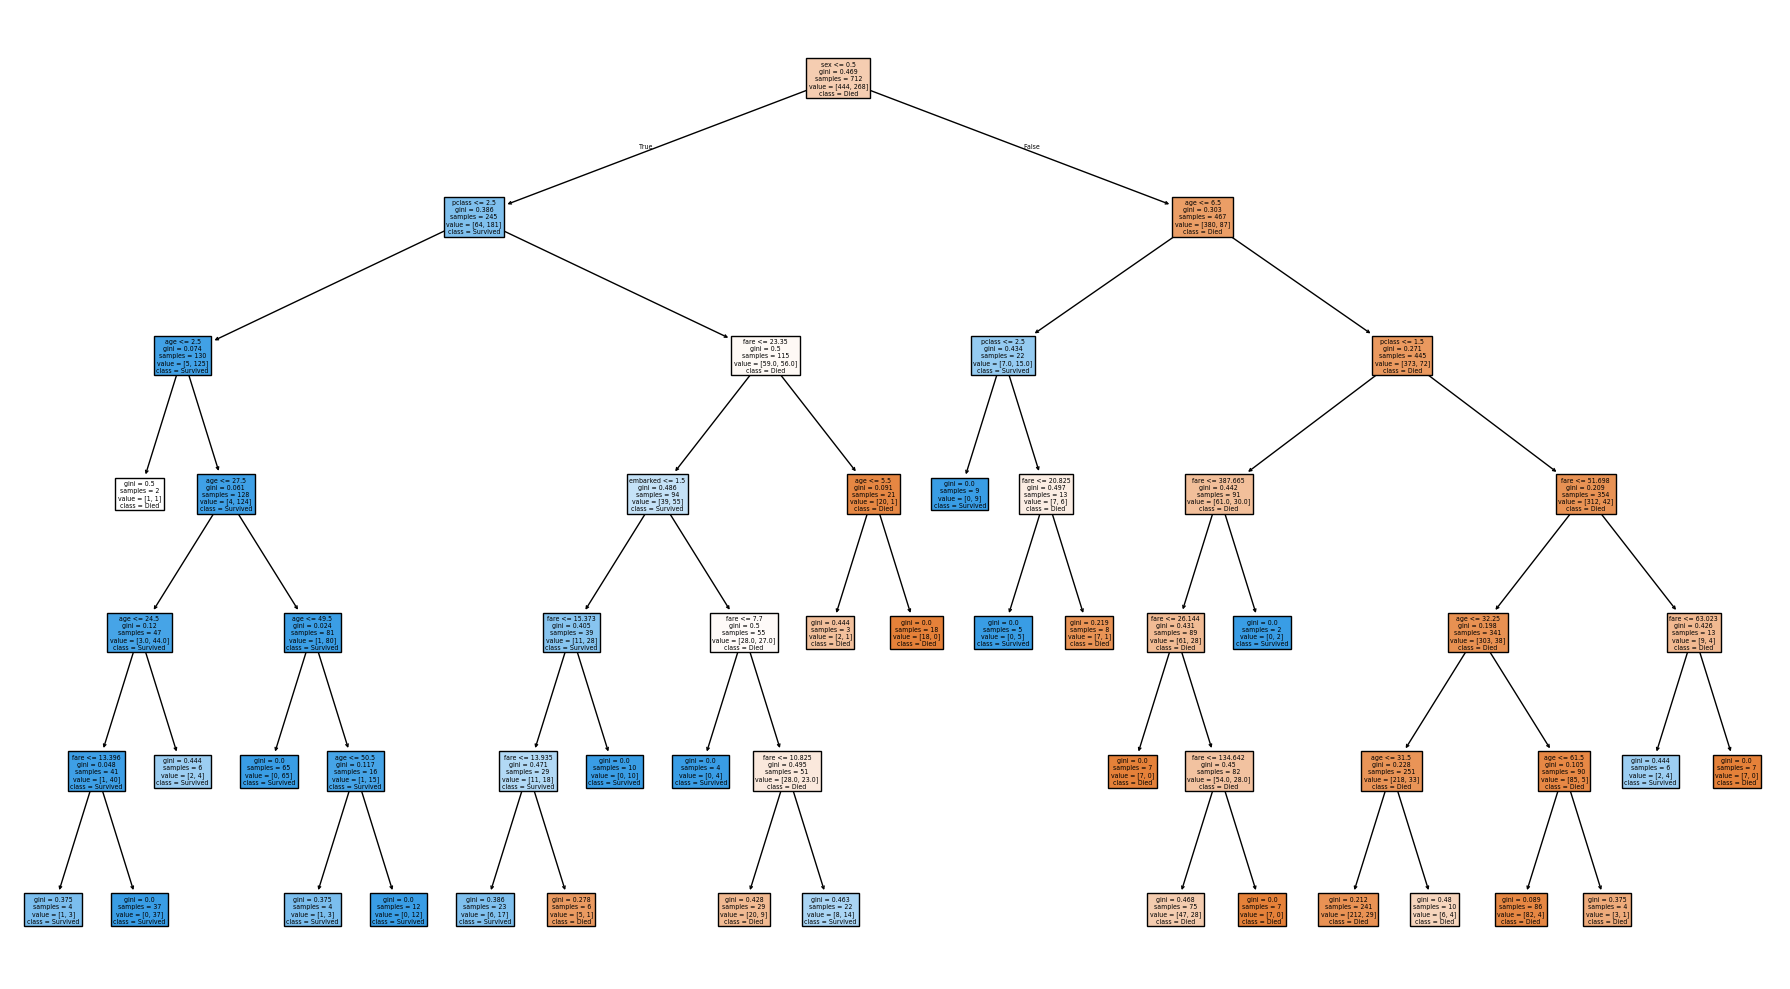

In [143]:
# plot eecision tree
from sklearn.tree import plot_tree

plt.figure(figsize = (18,10))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    # fontsize=20,
    # max_depth = 2
)

plt.tight_layout()
plt.show()


## Post Pruning

In [144]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [145]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [146]:
# train our model for all alphas
tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha = alpha)
    model.fit(X_train, y_train)
    

    tree.append((model, alpha))
                     

In [147]:
best_acc = 0
best_alpha = 0

for model, alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc> best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [148]:
best_alpha

np.float64(0.0015407231242023183)

In [149]:
best_acc

0.8379888268156425

In [165]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha, max_depth = 10)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


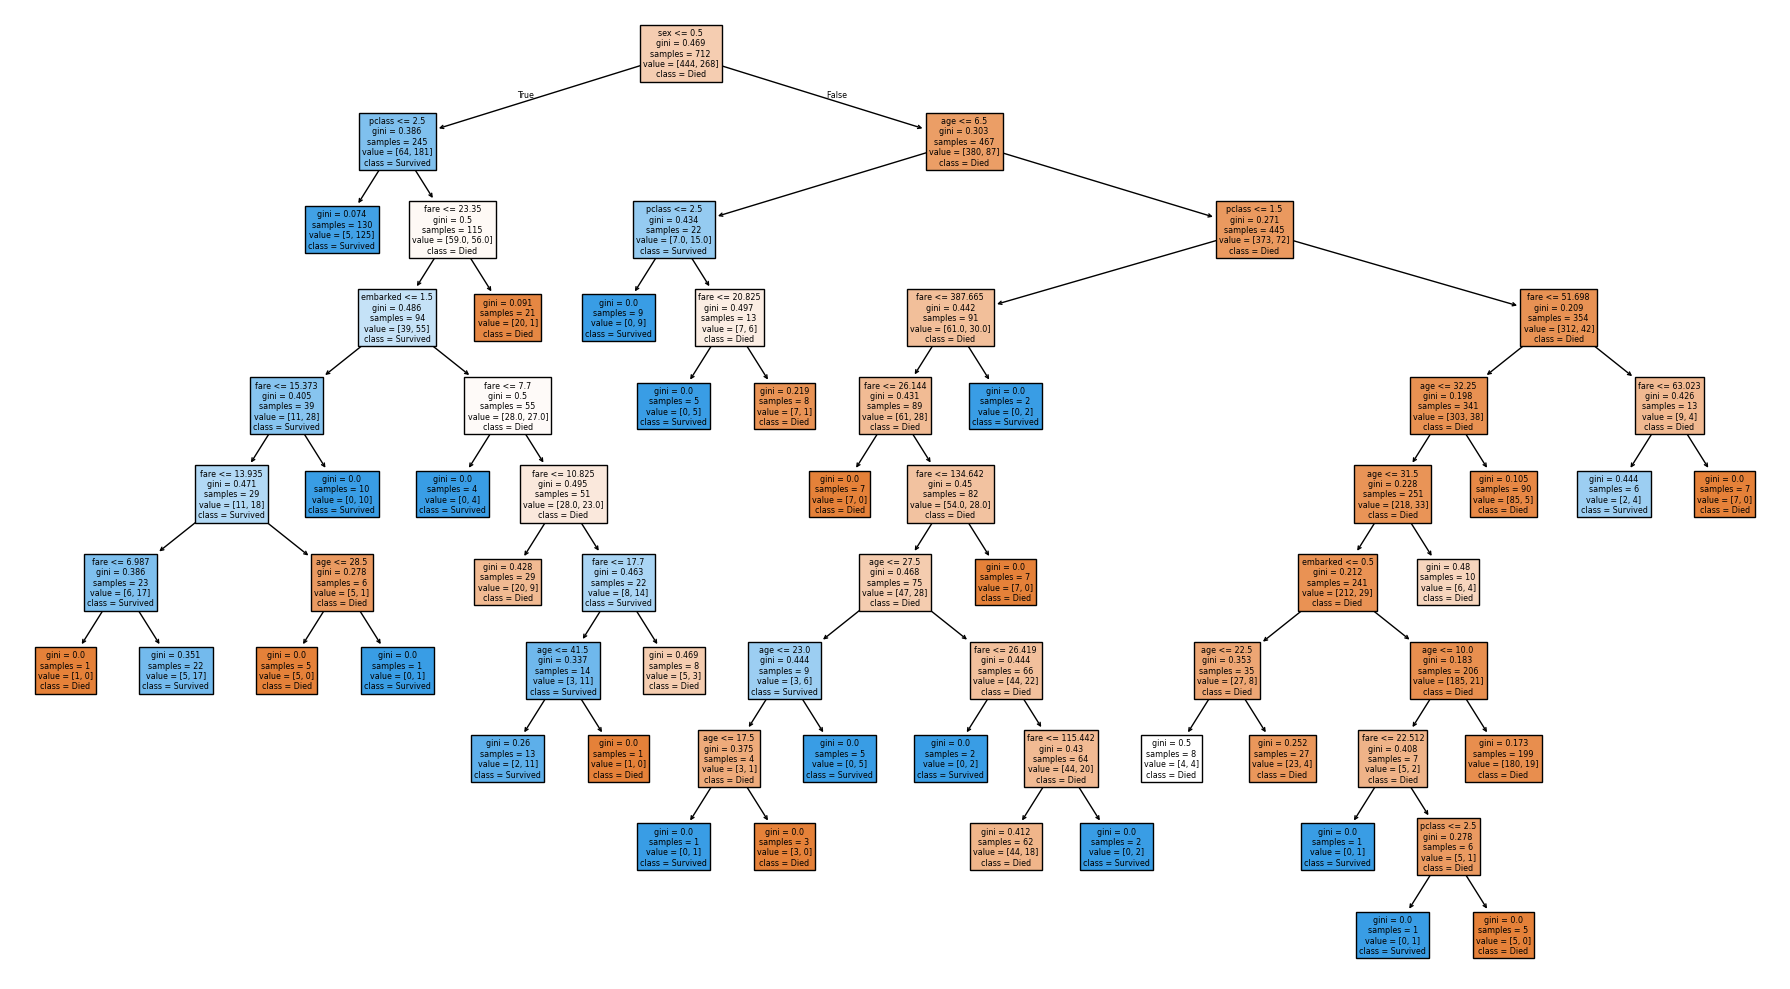

In [157]:
plt.figure(figsize = (18,10))

plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    # fontsize=20,
    # max_depth = 2
)

plt.tight_layout()
plt.show()

In [166]:
print(best_model.score(X_test, y_test))

0.8379888268156425
